<a href="https://colab.research.google.com/github/saninduhansara/Air-Pollution-Forecasting-Using-Temporal-NNs/blob/main/Air_Pollution_Forecasting_Using_Temporal_NN_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Imports and setup**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')

#**Data Loading and Datetime Parsing**

In [17]:
# Load the raw training data
df = pd.read_csv('train_raw.csv')

# Create a proper datetime column and sort the dataset
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values(by=['station', 'date']).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (315648, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


#**Exploratory Data Analysis & Visualizations**

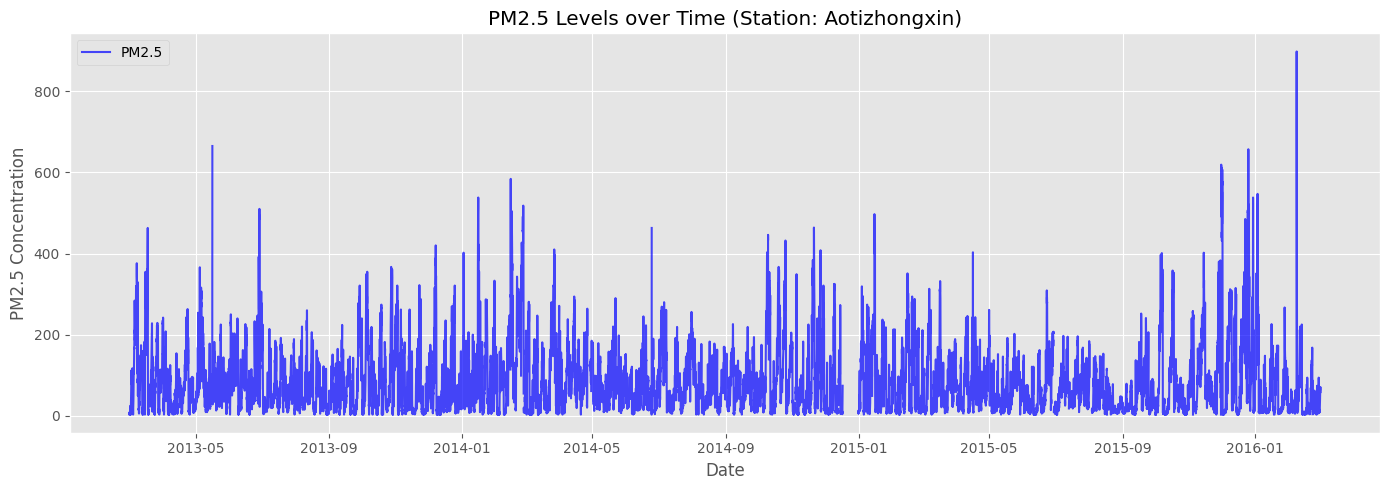

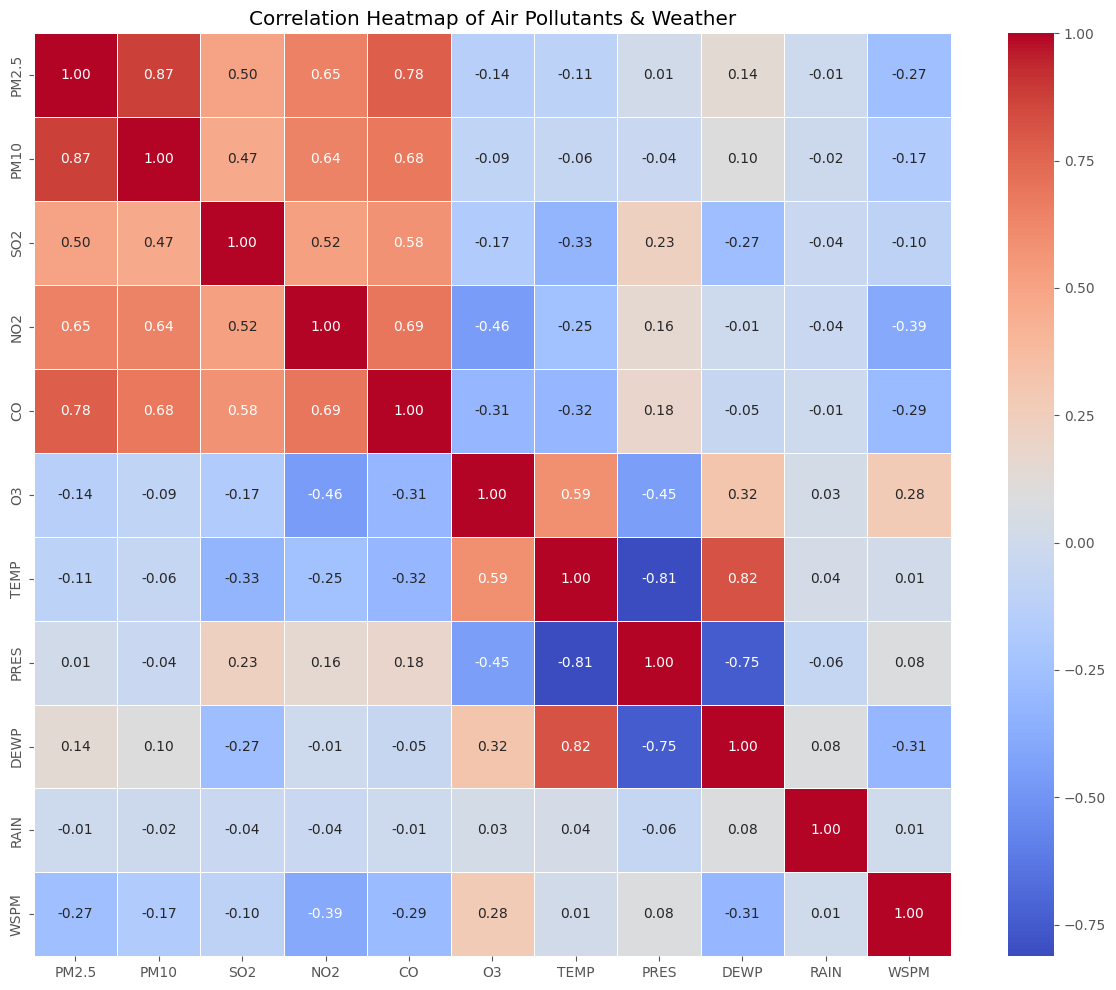

In [18]:
# 1. Plot PM2.5 Time Series for a single station (e.g., Aotizhongxin)
plt.figure(figsize=(14, 5))
sample_station = df[df['station'] == 'Aotizhongxin']
plt.plot(sample_station['date'], sample_station['PM2.5'], label='PM2.5', color='blue', alpha=0.7)
plt.title('PM2.5 Levels over Time (Station: Aotizhongxin)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (Fixed: Only using numeric columns)
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Exclude structural columns from heatmap
heatmap_cols = [c for c in numeric_cols if c not in ['No', 'year', 'month', 'day', 'hour']]

sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Air Pollutants & Weather')
plt.tight_layout()
plt.show()

#**Station-Aware Missing Value Imputation**

In [19]:
# Group by station to prevent cross-contamination during imputation
def impute_missing(group):
    # Interpolate forward, then backward fill remaining NaNs at the start
    return group.interpolate(method='linear', limit_direction='forward').bfill()

# Apply the imputation station by station
df = df.groupby('station', group_keys=False).apply(impute_missing)

# Check to ensure no missing values remain
print("Missing values after station-aware imputation:")
print(df.isnull().sum())

Missing values after station-aware imputation:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
date       0
dtype: int64


#**Feature Engineering**

In [20]:
# 1. Cyclic time features
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 23.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 23.0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

# 2. One-hot encode wind direction
df['wd'] = df['wd'].ffill().bfill()
df = pd.get_dummies(df, columns=['wd'], dtype=float)

# 3. One-hot encode station (Keep the original 'station' column!)
station_dummies = pd.get_dummies(df['station'], prefix='station', dtype=float)
df = pd.concat([df, station_dummies], axis=1)

# 4. Define the final feature list
wd_cols = [col for col in df.columns if col.startswith('wd_')]
station_cols = [col for col in df.columns if col.startswith('station_')]

base_features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
time_features = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']

# Combine all features for the model
all_features = base_features + wd_cols + station_cols + time_features
target = 'PM2.5'

#**Chronological Train & Validation Split**

In [21]:
# Chronological Split
train_mask = df['date'] < '2015-09-01'

train_df = df[train_mask].copy()
val_df = df[~train_mask].copy()

print(f"Training rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")

Training rows: 263232
Validation rows: 52416


#**Scaling and Target Transformation**

In [22]:
# Initialize Scalers
feature_scaler = MinMaxScaler()
# We need a separate scaler for the target so we can inverse_transform later
target_scaler = MinMaxScaler()

# Log-transform the target variable to handle extreme outliers
train_df['PM2.5_log'] = np.log1p(train_df['PM2.5'])
val_df['PM2.5_log'] = np.log1p(val_df['PM2.5'])

# Fit scalers on TRAINING data only
train_df[all_features] = feature_scaler.fit_transform(train_df[all_features])
train_df[['PM2.5_log_scaled']] = target_scaler.fit_transform(train_df[['PM2.5_log']])

# Transform VALIDATION data
val_df[all_features] = feature_scaler.transform(val_df[all_features])
val_df[['PM2.5_log_scaled']] = target_scaler.transform(val_df[['PM2.5_log']])

#**24-Hour Sequence Generation**

In [23]:
def create_sequences_per_station(data, feature_cols, target_col, window_size=24):
    X, y = [], []
    # Group by station to ensure windows don't cross station boundaries
    for station_name, group in data.groupby('station'):
        group_features = group[feature_cols].values
        group_target = group[target_col].values

        for i in range(len(group) - window_size):
            X.append(group_features[i : i + window_size])
            y.append(group_target[i + window_size])

    return np.array(X), np.array(y)

window_size = 24

# Create Train Sequences
print("Generating training sequences...")
X_train, y_train = create_sequences_per_station(
    train_df,
    feature_cols=all_features,
    target_col='PM2.5_log_scaled',
    window_size=window_size
)

# Create Validation Sequences
print("Generating validation sequences...")
X_val, y_val = create_sequences_per_station(
    val_df,
    feature_cols=all_features,
    target_col='PM2.5_log_scaled',
    window_size=window_size
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

Generating training sequences...
Generating validation sequences...
X_train shape: (262944, 24, 43)
y_train shape: (262944,)
X_val shape: (52128, 24, 43)
y_val shape: (52128,)


#**Building the Temporal Neural Network**

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the model architecture
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1) # Predicting a single numerical value
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        27,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,761 (116.25 KB)

 Trainable params: 29,761 (116.25 KB)

 Non-trainable params: 0 (0.00 B)

#**Training the Model**

Training model...
Epoch 1/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0068 - val_loss: 0.0035
Epoch 2/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0034 - val_loss: 0.0029
Epoch 3/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 4/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 5/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 6/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0027 - val_loss: 0.0031
Epoch 7/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 8/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 9/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 10/30
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0026 - val_loss: 0.0027


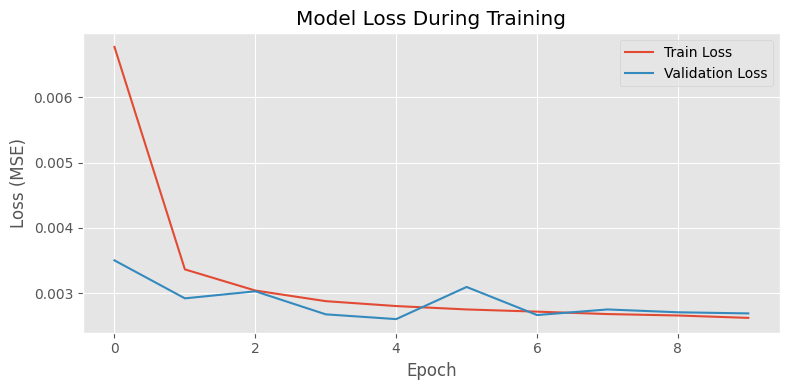

In [25]:
# Setup Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
print("Training model...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Plot training & validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

#**Validation & Kaggle Evaluation Metric**

In [26]:
# 1. Make predictions on the validation set
val_preds_scaled = model.predict(X_val)

# 2. Inverse MinMax Scaling
val_preds_log = target_scaler.inverse_transform(val_preds_scaled)
y_val_log = target_scaler.inverse_transform(y_val.reshape(-1, 1))

# 3. Inverse Log Transformation (np.expm1 is the inverse of np.log1p)
val_preds_actual = np.expm1(val_preds_log)
y_val_actual = np.expm1(y_val_log)

# 4. Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_val_actual, val_preds_actual))
mae = mean_absolute_error(y_val_actual, val_preds_actual)

print(f"Validation Baseline RMSE: {rmse:.2f}")
print(f"Validation Baseline MAE: {mae:.2f}")

1629/1629 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Validation Baseline RMSE: 22.33
Validation Baseline MAE: 10.58


#**Visualizing Actual vs. Predicted PM2.5 for All Stations**

Generating prediction plots for all stations...


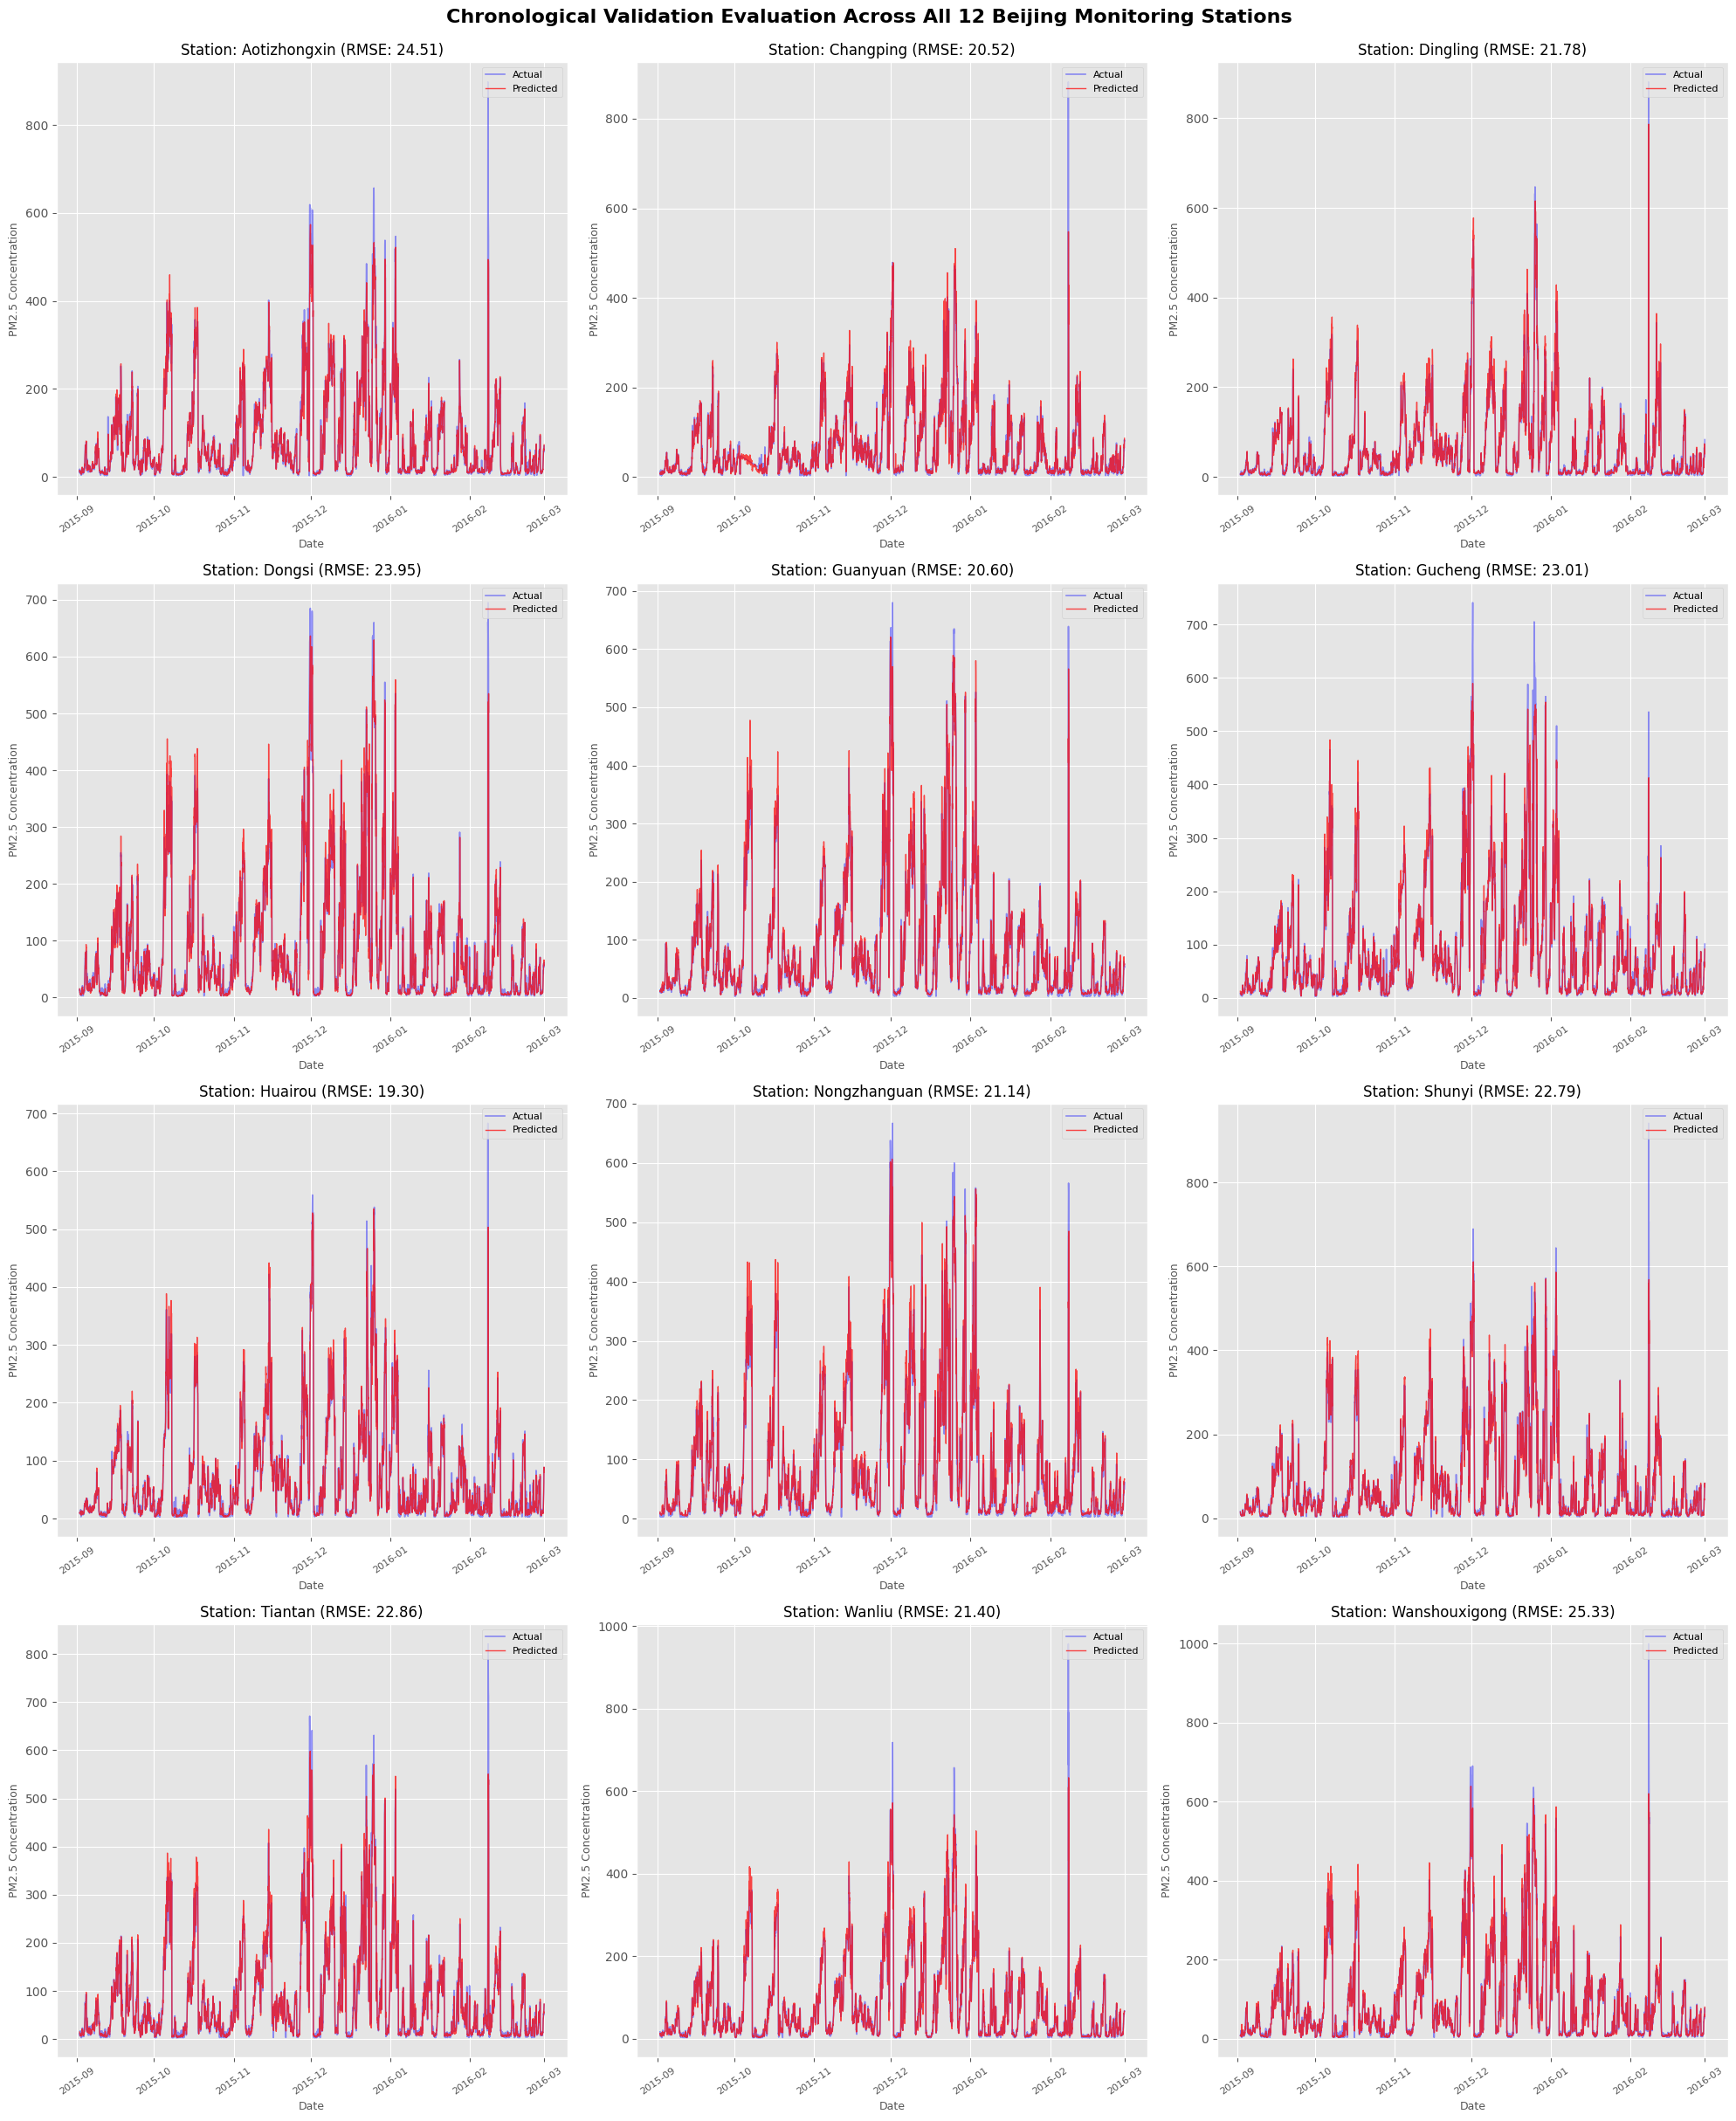

In [30]:
# Get a unique list of all 12 stations present in the validation data
unique_stations = val_df['station'].unique()

# Initialize a grid of subplots (4 rows x 3 columns = 12 subplots)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 24), sharex=False)
axes = axes.flatten() # Flatten the 2D grid array into 1D for easy iteration

print("Generating prediction plots for all stations...")

for idx, station_name in enumerate(unique_stations):
    # 1. Filter validation data for the current station
    station_val_df = val_df[val_df['station'] == station_name].copy()

    # 2. Extract aligned timestamps (skipping the first 24 hours used for the initial window)
    target_dates = station_val_df['date'].iloc[window_size:].values

    # 3. Create station-isolated sequences
    X_station_val, y_station_val = create_sequences_per_station(
        station_val_df,
        feature_cols=all_features,
        target_col='PM2.5_log_scaled',
        window_size=window_size
    )

    # 4. Predict using the global model
    station_preds_scaled = model.predict(X_station_val, verbose=0)

    # 5. Reverse target transformations (Inverse MinMax Scaling -> Inverse Log)
    station_preds_log = target_scaler.inverse_transform(station_preds_scaled)
    y_station_val_log = target_scaler.inverse_transform(y_station_val.reshape(-1, 1))

    station_preds_actual = np.expm1(station_preds_log)
    y_station_val_actual = np.expm1(y_station_val_log)

    # 6. Plot the station results on its assigned subplot index
    ax = axes[idx]
    ax.plot(target_dates, y_station_val_actual, label='Actual', color='blue', alpha=0.4, linewidth=1.2)
    ax.plot(target_dates, station_preds_actual, label='Predicted', color='red', alpha=0.7, linewidth=1.0)

    # Calculate local station performance metrics
    station_rmse = np.sqrt(mean_squared_error(y_station_val_actual, station_preds_actual))

    # Subplot formatting
    ax.set_title(f"Station: {station_name} (RMSE: {station_rmse:.2f})", fontsize=12)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('PM2.5 Concentration', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=35, labelsize=8)

# Adjust layout structure to prevent overlapping text elements
plt.tight_layout()
plt.suptitle('Chronological Validation Evaluation Across All 12 Beijing Monitoring Stations', fontsize=16, y=1.01, weight='bold')
plt.show()

#**Processing the Test Set and Creating the Submission**

In [28]:
# 1. Load the test dataset
test_df = pd.read_csv('test.csv')

# 2. Impute missing values in the test set
test_df = test_df.bfill(axis=1).ffill(axis=1)

# 3. One-hot encode station in the test set
station_dummies_test = pd.get_dummies(test_df['station'], prefix='station', dtype=float)

# Ensure all station columns from the training set exist in the test set
for col in station_cols:
    if col not in station_dummies_test.columns:
        station_dummies_test[col] = 0.0

test_df = pd.concat([test_df, station_dummies_test], axis=1)

# 4. Reconstruct the 3D Sequences
num_samples = len(test_df)
num_features = len(all_features)
window_size = 24
X_test = np.zeros((num_samples, window_size, num_features))

for feature_idx, feature_name in enumerate(all_features):
    if feature_name in station_cols:
        # Station features don't have lags; duplicate the single value 24 times
        feature_data = test_df[feature_name].values
        feature_data_reshaped = np.tile(feature_data, (window_size, 1)).T
    else:
        # Standard lagged features
        lag_cols = [f"{feature_name}_lag_{lag}" for lag in range(24, 0, -1)]
        feature_data_reshaped = test_df[lag_cols].values

    # Scale the feature using the feature_scaler fitted ONLY on train_df
    feature_data_scaled = feature_scaler.data_min_[feature_idx] + \
                          (feature_data_reshaped - feature_scaler.data_min_[feature_idx]) * \
                          feature_scaler.scale_[feature_idx]

    # Assign to the 3D tensor
    X_test[:, :, feature_idx] = feature_data_scaled

# 5. Make Predictions
test_preds_scaled = model.predict(X_test)

# 6. Inverse Transformations
test_preds_log = target_scaler.inverse_transform(test_preds_scaled)
test_preds_actual = np.expm1(test_preds_log)

# 7. Format Submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'PM2.5': test_preds_actual.flatten()
})

submission.to_csv('submission.csv', index=False)
print("Submission saved successfully! Ready to upload to Kaggle.")
display(submission.head())

FileNotFoundError: [Errno 2] No such file or directory: 'test.csv'